In [81]:
import eurostat
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Ustawienia wykresów
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Kod kraju → pełna nazwa
COUNTRY_NAMES = {
    'AT': 'Austria',       'BE': 'Belgia',        'BG': 'Bułgaria',
    'CY': 'Cypr',          'CZ': 'Czechy',           'DE': 'Niemcy',
    'DK': 'Dania',         'EE': 'Estonia',         'EL': 'Grecja',
    'ES': 'Hiszpania',       'FI': 'Finlandia',       'FR': 'Francja',
    'HR': 'Chorwacja',      'HU': 'Węgry',         'IE': 'Irlandia',
    'IT': 'Włochy',        'LT': 'Litwa',            'LU': 'Luksemburg',
    'LV': 'Łotwa',        'MT': 'Malta',           'NL': 'Holandia',
    'PL': 'Polska',        'PT': 'Portugalia',       'RO': 'Rumunia',
    'SE': 'Szwecja',        'SI': 'Słowenia',         'SK': 'Słowacja',
    'UK': 'Wielka Brytania','NO': 'Norwegia',         'CH': 'Szwajcaria',
    'IS': 'Islandia',      'TR': 'Turcja',           'RS': 'Serbia',
    'ME': 'Czarnogóra',    'MK': 'Macedonia Północna','AL': 'Albania',
    'BA': 'Bośnia i Hercegowina', 'XK': 'Kosowo',   'MD': 'Mołdowia',
    'UA': 'Ukraina',       'BY': 'Białoruś',         'RU': 'Rosja',
    'LI': 'Liechtenstein',  'EU': 'ЕU (zespół)',     'EA': 'Strefa europejska',
}

def label(code):
    #Zwraca pełną nazwę kraju lub kod, jeśli nie ma nazwy
    return COUNTRY_NAMES.get(code, code)



In [82]:
# Ładowanie danych przez bibliotekę eurostat
DATASET_CODE = 'tran_r_avpa_nm'

raw = eurostat.get_data_df(DATASET_CODE)
raw.head()

,freq,tra_meas,unit,geo\TIME_PERIOD,1993,1994,1995,1996,1997,1998,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,A,PAS_CRD,THS_PAS,AT,NaN,NaN,NaN,NaN,NaN,NaN,...,26753.42,27180.94,28325.54,31136.91,35643.48,9168.42,11105.20,26380.92,33062.59,35281.68
1,A,PAS_CRD,THS_PAS,AT1,NaN,NaN,NaN,NaN,NaN,NaN,...,22739.59,23318.17,24333.36,27024.79,31634.90,7848.37,10466.12,23788.39,29655.36,31737.61
2,A,PAS_CRD,THS_PAS,AT12,NaN,NaN,NaN,NaN,NaN,NaN,...,22739.59,23318.17,24333.36,27024.79,31634.90,7848.37,10466.12,23788.39,29655.36,31737.61
3,A,PAS_CRD,THS_PAS,AT2,NaN,NaN,NaN,NaN,NaN,NaN,...,1185.79,1178.86,1168.53,1256.34,1245.12,249.43,255.97,643.57,889.50,961.25
4,A,PAS_CRD,THS_PAS,AT21,NaN,NaN,NaN,NaN,NaN,NaN,...,229.74,195.34,216.10,229.66,209.86,49.74,29.64,83.06,154.60,138.84


In [83]:
# Przetwarzanie  wstępne (pozostawiamy tylko dane na poziomie krajów (geo długie 2 znaki))
df_raw = raw.copy()

# Definiujemy kolumnę z geografią
geo_col = [c for c in df_raw.columns if 'geo' in c.lower()][0]
print('Kolumna geokodu:', geo_col)

# Filtrowanie (tylko kody o długości 2 znaków)
df_countries = df_raw[df_raw[geo_col].str.len() == 2].copy()
df_countries = df_countries.rename(columns={geo_col: 'geo'})

print(f'Kody krajów: {sorted(df_countries["geo"].unique())}')

Kolumna geokodu: geo\TIME_PERIOD
Kody krajów: ['AT', 'BA', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE', 'DK', 'EE', 'EL', 'ES', 'FI', 'FR', 'HR', 'HU', 'IE', 'IS', 'IT', 'LT', 'LU', 'LV', 'ME', 'MK', 'MT', 'NL', 'NO', 'PL', 'PT', 'RO', 'RS', 'SE', 'SI', 'SK', 'TR', 'UK']


In [84]:
# Określanie struktury kolumn
year_cols = [c for c in df_countries.columns if str(c).isdigit()]
meta_cols = [c for c in df_countries.columns if c not in year_cols + ['geo']]

print('Meta-kolumny:', meta_cols)
print('Lata:', year_cols[:5], '...', year_cols[-5:])
for col in meta_cols:
    print(f'  {col}: {df_countries[col].unique()}')

Meta-kolumny: ['freq', 'tra_meas', 'unit']
Lata: ['1993', '1994', '1995', '1996', '1997'] ... ['2020', '2021', '2022', '2023', '2024']
  freq: <ArrowStringArray>
['A']
Length: 1, dtype: str
  tra_meas: <ArrowStringArray>
['PAS_CRD', 'PAS_CRD_ARR', 'PAS_CRD_DEP']
Length: 3, dtype: str
  unit: <ArrowStringArray>
['THS_PAS']
Length: 1, dtype: str


In [85]:
# Wybór wymiaru podstawowego
df_work = df_countries.copy()

for col in meta_cols:
    if df_work[col].nunique() > 1:
        chosen = df_work[col].value_counts().idxmax()
        df_work = df_work[df_work[col] == chosen]
        print(f'Wybrane {col} = {chosen}')

Wybrane tra_meas = PAS_CRD


In [86]:
# wierszy = kraje, kolumny = lata
def clean_value(v):
    if isinstance(v, str):
        v = v.strip()
        if v in (':', ': ', '', 'p', 'b', 'e', 'd', 'n', 'u', 'z'):
            return np.nan
        v = v.split()[0] if ' ' in v else v
        try:
            return float(v.replace(',', '.'))
        except ValueError:
            return np.nan
    return v

df_pivot = df_work[['geo'] + year_cols].set_index('geo')

df_pivot.columns = [int(c) for c in df_pivot.columns]
df_pivot = df_pivot.dropna(how='all').sort_index(axis=1)

# Zmiana nazw indeksu (kody → pełne nazwy)
df_pivot.index = [label(c) for c in df_pivot.index]
df_pivot.index.name = 'Kraj'

print(f'Tabela końcowa: {df_pivot.shape[0]} krajów × {df_pivot.shape[1]} lat')
print(f'Lata: {df_pivot.columns.min()} – {df_pivot.columns.max()}')
df_pivot.head(10)

Tabela końcowa: 36 krajów × 32 lat
Lata: 1993 – 2024


,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Kraj,,,,,,,,,,,,,,,,,,,,,
Austria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14944.0,...,26753.42,27180.94,28325.54,31136.91,35643.48,9168.42,11105.20,26380.92,33062.59,35281.68
Bośnia i Hercegowina,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,987.66,1770.61,1917.08,2002.14
Belgia,10029.0,11235.0,12505.0,13355.0,15923.0,18482.0,20002.0,21595.0,NaN,13559.0,...,30953.07,30113.92,33257.74,34504.09,35383.19,9465.21,13499.70,27872.41,32340.36,34758.23
Bułgaria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7608.79,9323.41,11091.96,12136.37,11711.77,3728.40,5047.73,8807.50,10561.51,10961.38
Szwajcaria,18140.0,19357.0,20501.0,21329.0,23376.0,24742.0,27008.0,NaN,NaN,25460.0,...,41752.50,43812.76,46361.81,48318.03,48834.31,13760.60,15963.95,36333.66,44985.01,48532.39
Cypr,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6540.0,NaN,...,7590.79,8961.82,10238.91,10927.10,11261.41,2270.58,5099.70,9200.93,11616.24,12264.97
Czechy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6579.0,...,12672.00,13672.36,16245.55,17838.22,18767.09,3821.37,4755.16,11532.65,14924.87,17746.11
Niemcy,58845.0,64556.0,84943.0,87902.0,93979.0,104534.0,112191.0,120798.0,118289.0,114383.0,...,193924.98,200679.35,212381.00,222415.54,226755.00,57791.54,73595.31,155296.04,185273.43,199548.64
Dania,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,30083.44,32762.06,33258.99,34699.34,34778.45,8657.42,10816.66,26648.80,31734.67,34864.37


In [87]:
# df.info()
print('df.info()')
df_pivot.info()

df.info()
<class 'pandas.DataFrame'>
Index: 36 entries, Austria to Wielka Brytania
Data columns (total 32 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   1993    12 non-null     float64
 1   1994    11 non-null     float64
 2   1995    11 non-null     float64
 3   1996    11 non-null     float64
 4   1997    12 non-null     float64
 5   1998    12 non-null     float64
 6   1999    11 non-null     float64
 7   2000    10 non-null     float64
 8   2001    12 non-null     float64
 9   2002    18 non-null     float64
 10  2003    22 non-null     float64
 11  2004    27 non-null     float64
 12  2005    29 non-null     float64
 13  2006    29 non-null     float64
 14  2007    30 non-null     float64
 15  2008    31 non-null     float64
 16  2009    31 non-null     float64
 17  2010    31 non-null     float64
 18  2011    31 non-null     float64
 19  2012    31 non-null     float64
 20  2013    31 non-null     float64
 21  2014    31 non-null     floa

In [88]:
# df.describe()
print('df.describe()')
df_pivot.describe().round(1)

df.describe()


,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
count,12.0,11.0,11.0,11.0,12.0,12.0,11.0,10.0,12.0,18.0,...,32.0,33.0,33.0,34.0,34.0,33.0,34.0,34.0,35.0,35.0
mean,28009.7,34083.9,39075.0,40865.1,43591.9,47916.1,55248.4,62699.2,51366.2,40865.8,...,43136.1,44829.4,48388.4,44658.6,51347.2,11908.0,15972.5,34632.2,44861.2,48643.0
std,25306.0,27277.1,30844.1,32198.4,36269.5,42771.8,49283.3,54519.5,56010.6,49660.8,...,61468.1,64670.8,68811.6,64256.0,72943.8,16438.0,23221.1,49402.5,61441.9,66861.2
min,1013.0,8101.0,9781.0,9916.0,6442.0,9983.0,9796.0,10721.0,414.0,497.0,...,1436.0,1404.2,1682.1,1810.6,1719.0,287.8,419.4,968.8,1268.4,1437.7
25%,9573.5,15296.0,15909.0,15532.0,15035.5,17284.8,17619.0,18289.8,5614.0,7508.2,...,5071.2,5384.8,6078.0,6863.4,7384.4,1804.0,2443.8,5491.7,7216.1,7882.5
50%,19564.5,23649.0,25543.0,28046.0,27605.5,29799.0,27589.0,35680.0,28807.5,17808.5,...,22116.2,18099.3,20054.6,20989.2,22404.6,5428.5,5073.7,13102.9,16602.1,17814.1
75%,41839.2,47341.0,50160.0,53014.0,66295.0,72731.0,96025.5,106569.5,99028.5,59436.2,...,38564.2,40791.6,46361.8,47179.2,48360.5,13760.6,15507.0,35390.8,47575.8,52787.0
max,86372.7,95859.0,100971.0,104921.4,114155.4,142886.7,151441.1,162298.5,163031.0,168746.0,...,232260.1,248825.3,264614.2,272172.0,277419.7,57797.5,93185.2,201727.8,236040.8,259740.1


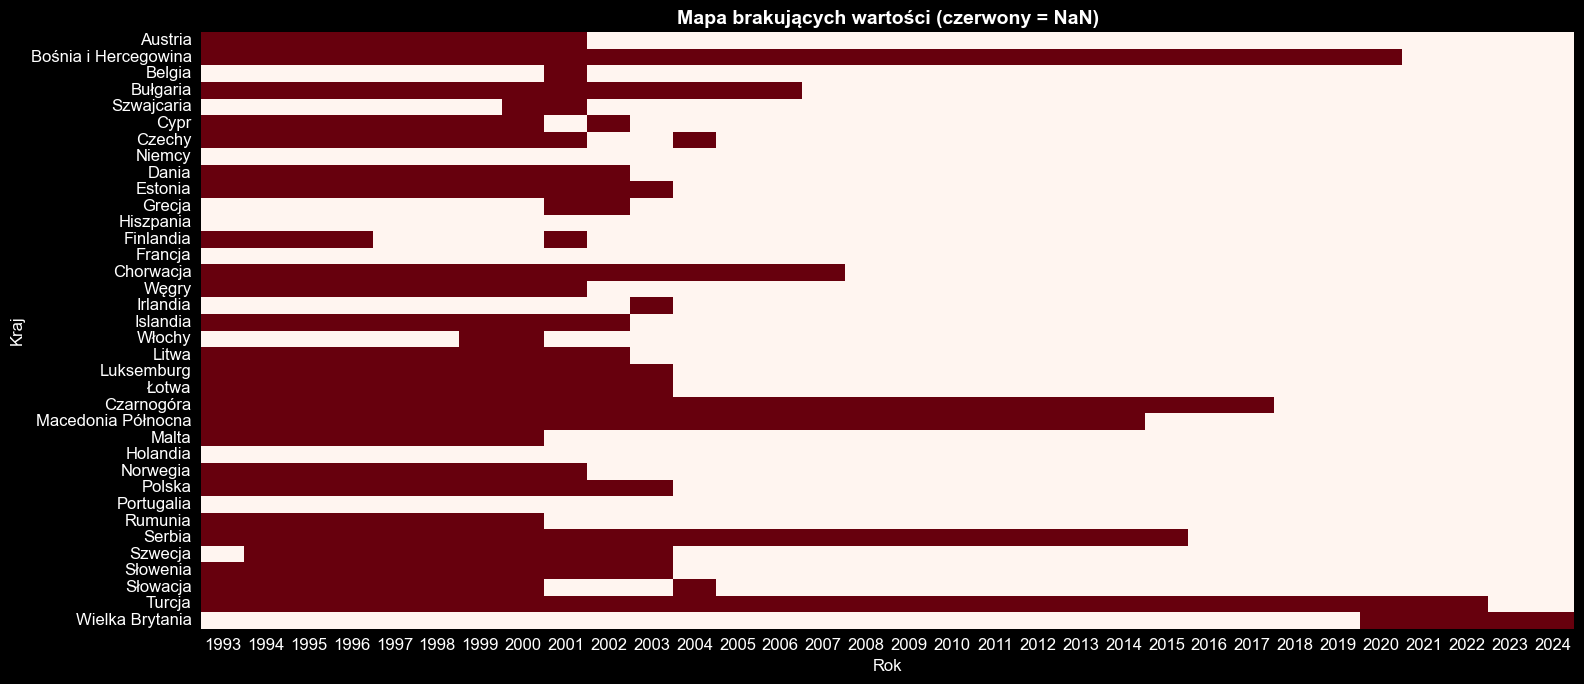

In [89]:
# Wykres 1: Mapa brakujących wartości
plt.figure(figsize=(16, 7))
sns.heatmap(df_pivot.isnull(), cbar=False, cmap='Reds',
            yticklabels=True, xticklabels=True)
plt.title('Mapa brakujących wartości (czerwony = NaN)', fontsize=14, fontweight='bold')
plt.xlabel('Rok')
plt.ylabel('Kraj')
plt.tight_layout()
plt.show()

In [90]:
# TOP-10 krajów w ciągu ostatniego roku
top10 = (
    df_pivot[LATEST_YEAR]
    .dropna()
    .sort_values(ascending=False)
    .head(10)
)
print(f'ТОP-10 krajów według liczby pasażerów ({LATEST_YEAR}):')
print(top10.apply(lambda x: f'{x:,.0f}').to_frame('Pasażery (tys.)'))

ТОP-10 krajów według liczby pasażerów (2024):
           Pasażery (tys.)
Kraj                      
Hiszpania          259,740
Niemcy             199,549
Turcja             182,640
Włochy             182,328
Francja            174,765
Holandia            76,265
Grecja              69,218
Portugalia          63,991
Polska              57,042
Szwajcaria          48,532


In [91]:
# Definicja listy krajów UE-27 i filtrowanie df_pivot
EU27_COUNTRIES_PL = [
    'Austria', 'Belgia', 'Bułgaria', 'Cypr', 'Czechy', 'Niemcy',
    'Dania', 'Estonia', 'Grecja', 'Hiszpania', 'Finlandia', 'Francja',
    'Chorwacja', 'Węgry', 'Irlandia', 'Włochy', 'Litwa', 'Luksemburg',
    'Łotwa', 'Malta', 'Holandia', 'Polska', 'Portugalia', 'Rumunia',
    'Szwecja', 'Słowenia', 'Słowacja'
]

df_eu27 = df_pivot[df_pivot.index.isin(EU27_COUNTRIES_PL)]
print(f'Kraje UE-27 w danych: {df_eu27.shape[0]}')
print(df_eu27.index.tolist())


Kraje UE-27 w danych: 27
['Austria', 'Belgia', 'Bułgaria', 'Cypr', 'Czechy', 'Niemcy', 'Dania', 'Estonia', 'Grecja', 'Hiszpania', 'Finlandia', 'Francja', 'Chorwacja', 'Węgry', 'Irlandia', 'Włochy', 'Litwa', 'Luksemburg', 'Łotwa', 'Malta', 'Holandia', 'Polska', 'Portugalia', 'Rumunia', 'Szwecja', 'Słowenia', 'Słowacja']


In [92]:
# Średnia roczna dla każdego kraju UE-27
df_eu27_mean = df_eu27.mean(axis=1).sort_values(ascending=False)
print('Średnia ze wszystkich lat — UE-27 (tys.pas.):')
print(df_eu27_mean.apply(lambda x: f'{x:,.1f}').to_frame('Średnia'))

Średnia ze wszystkich lat — UE-27 (tys.pas.):
              Średnia
Kraj                 
Niemcy      144,393.2
Hiszpania   134,332.4
Francja     112,255.7
Włochy       95,570.0
Holandia     48,886.8
Grecja       35,423.5
Portugalia   27,363.1
Szwecja      26,858.2
Polska       26,588.8
Dania        24,949.2
Austria      23,869.0
Irlandia     22,793.0
Belgia       21,978.0
Finlandia    14,020.3
Czechy       12,238.8
Rumunia      10,925.8
Węgry         9,605.8
Bułgaria      7,974.6
Cypr          7,770.7
Chorwacja     6,954.4
Łotwa         4,536.4
Malta         4,205.0
Litwa         3,462.8
Luksemburg    2,592.3
Estonia       2,039.0
Słowacja      1,772.7
Słowenia      1,289.6


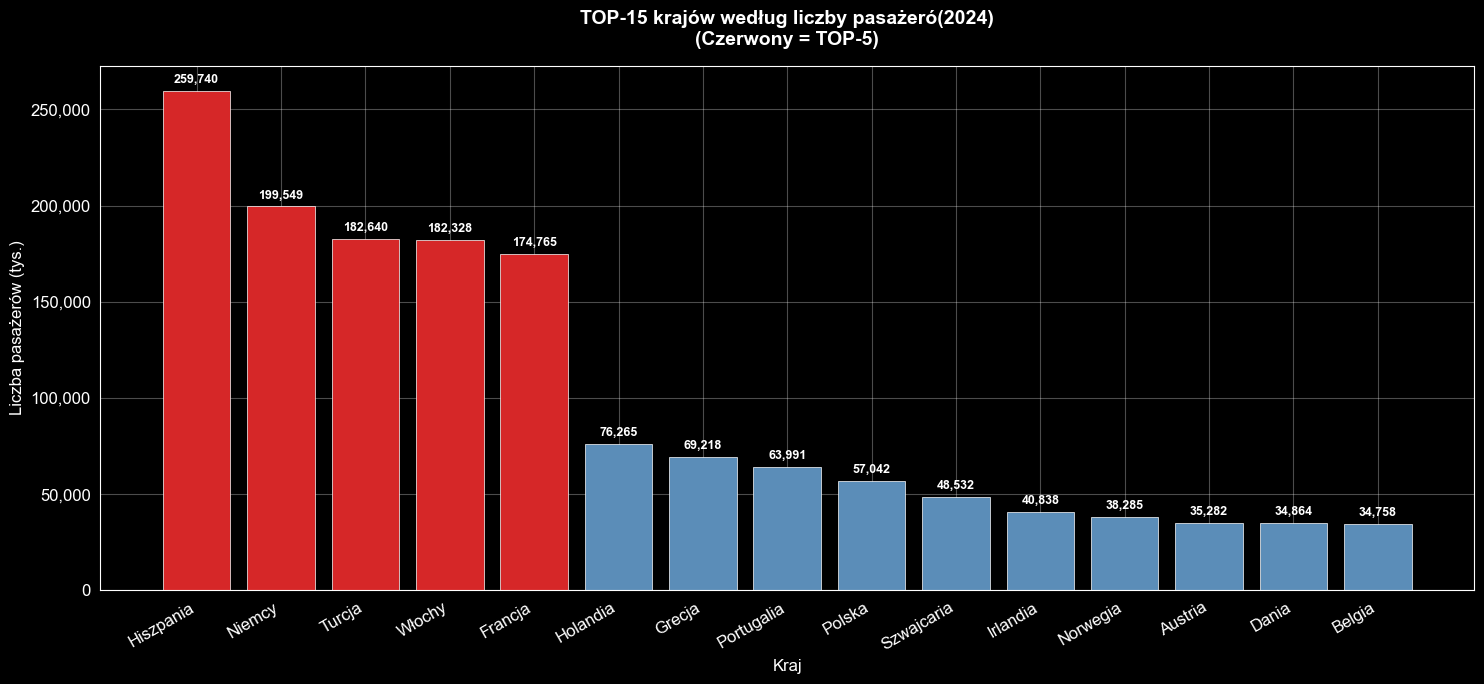

In [93]:
# Wykres 2: ТОP-15 krajów w ciągu ostatniego roku
TOP5 = top10.head(5).index.tolist()
top15 = (
    df_pivot[LATEST_YEAR]
    .dropna()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(15, 7))
bar_colors = ['#d62728' if c in TOP5 else '#5B8DB8' for c in top15.index]
bars = ax.bar(top15.index, top15.values, color=bar_colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, top15.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + top15.max()*0.01,
            f'{val/1000:.1f}M' if val >= 1e6 else f'{val:,.0f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title(f'ТОP-15 krajów według liczby pasażeró({LATEST_YEAR})\n(Czerwony = ТОP-5)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Kraj', fontsize=12)
ax.set_ylabel('Liczba pasażerów (tys.)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}M' if x >= 1e6 else f'{x:,.0f}'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [94]:
# Statystyki opisowe dla ostatniego roku
year_data = df_pivot[LATEST_YEAR].dropna()

stats_dict = {
    'Średnie:':         year_data.mean(),
    'Mediana:':       year_data.median(),
    'Odchylenie standardowe:': year_data.std(),
    'Rozproszenie:':              year_data.var(),
    'Minimum:':                year_data.min(),
    'Maksimum:':               year_data.max(),
    'Q1 (25%)':               year_data.quantile(0.25),
    'Q3 (75%)':               year_data.quantile(0.75),
    'IQR':                    year_data.quantile(0.75) - year_data.quantile(0.25),
}
stats_df = pd.DataFrame.from_dict(stats_dict, orient='index', columns=['Wartość'])
stats_df['Wartość'] = stats_df['Wartość'].apply(lambda x: f'{x:,.2f}')
print(f'Statystyki opispwe dla {LATEST_YEAR}:')
print(stats_df)

Statystyki opispwe dla 2024:
                                  Wartość
Średnie:                        48,642.99
Mediana:                        17,814.13
Odchylenie standardowe:         66,861.21
Rozproszenie:            4,470,421,423.81
Minimum:                         1,437.66
Maksimum:                      259,740.14
Q1 (25%)                         7,882.51
Q3 (75%)                        52,786.98
IQR                             44,904.47


In [95]:
# ТОP-5 krajów do analizy szeregów czasowych
print(f'ТОP-5 krajów: {TOP5}')
df_top5 = df_pivot.loc[TOP5]
df_top5_clean = df_top5.dropna(axis=1, how='all')
colors = ['#1f77b4','#d62728','#2ca02c','#ff7f0e','#9467bd']

ТОP-5 krajów: ['Hiszpania', 'Niemcy', 'Turcja', 'Włochy', 'Francja']


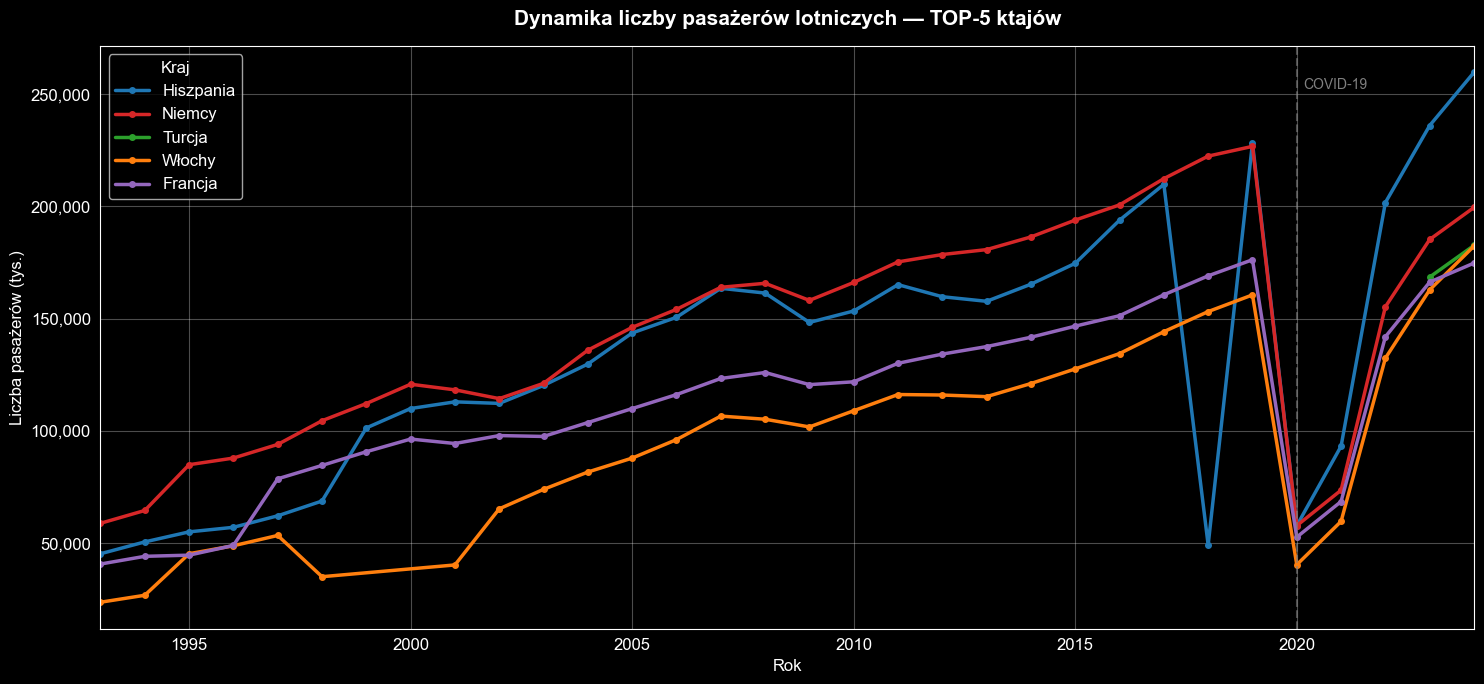

In [96]:
# Wykres 3: Dynamika TOP-5 krajów
fig, ax = plt.subplots(figsize=(15, 7))
for i, country in enumerate(TOP5):
    series = df_pivot.loc[country].dropna()
    ax.plot(series.index, series.values, marker='o', markersize=4,
            linewidth=2.5, label=country, color=colors[i])

ax.set_title('Dynamika liczby pasażerów lotniczych — ТОP-5 ktajów',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Rok', fontsize=12)
ax.set_ylabel('Liczba pasażerów (tys.)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}M' if x >= 1e6 else f'{x:,.0f}'))
ax.legend(fontsize=12, title='Kraj')
ax.set_xlim(df_pivot.columns.min(), df_pivot.columns.max())
if 2020 in df_pivot.columns:
    ax.axvline(x=2020, color='gray', linestyle='--', alpha=0.6, linewidth=1.5)
    ax.text(2020.15, ax.get_ylim()[1]*0.93, 'COVID-19', color='gray', fontsize=10)
plt.tight_layout()
plt.show()

In [97]:
# Łańcuchowe stopy wzrostu (% zmiana rok do roku)
df_growth = df_pivot.pct_change(axis=1) * 100
print('Łańcuchowe stopy wzrostu (%) — ТОP-5 krajów:')
df_growth.loc[TOP5].dropna(axis=1, how='all').round(1)

Łańcuchowe stopy wzrostu (%) — ТОP-5 krajów:


,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Kraj,,,,,,,,,,,,,,,,,,,,,
Hiszpania,11.7,8.9,3.7,9.0,10.6,47.3,8.5,2.7,-0.6,7.1,...,5.6,11.0,8.2,-76.6,364.0,-74.7,61.2,116.5,17.0,10.0
Niemcy,9.7,31.6,3.5,6.9,11.2,7.3,7.7,-2.1,-3.3,6.0,...,4.0,3.5,5.8,4.7,2.0,-74.5,27.3,111.0,19.3,7.7
Turcja,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.4
Włochy,13.1,69.1,7.8,9.4,-34.4,NaN,NaN,NaN,62.1,13.3,...,5.4,5.3,7.3,6.2,4.8,-74.8,47.8,121.8,23.0,12.0
Francja,8.4,1.2,9.7,60.6,7.6,7.2,6.2,-2.0,3.7,-0.4,...,3.5,3.2,6.1,5.3,4.2,-70.1,30.1,107.1,17.2,5.1


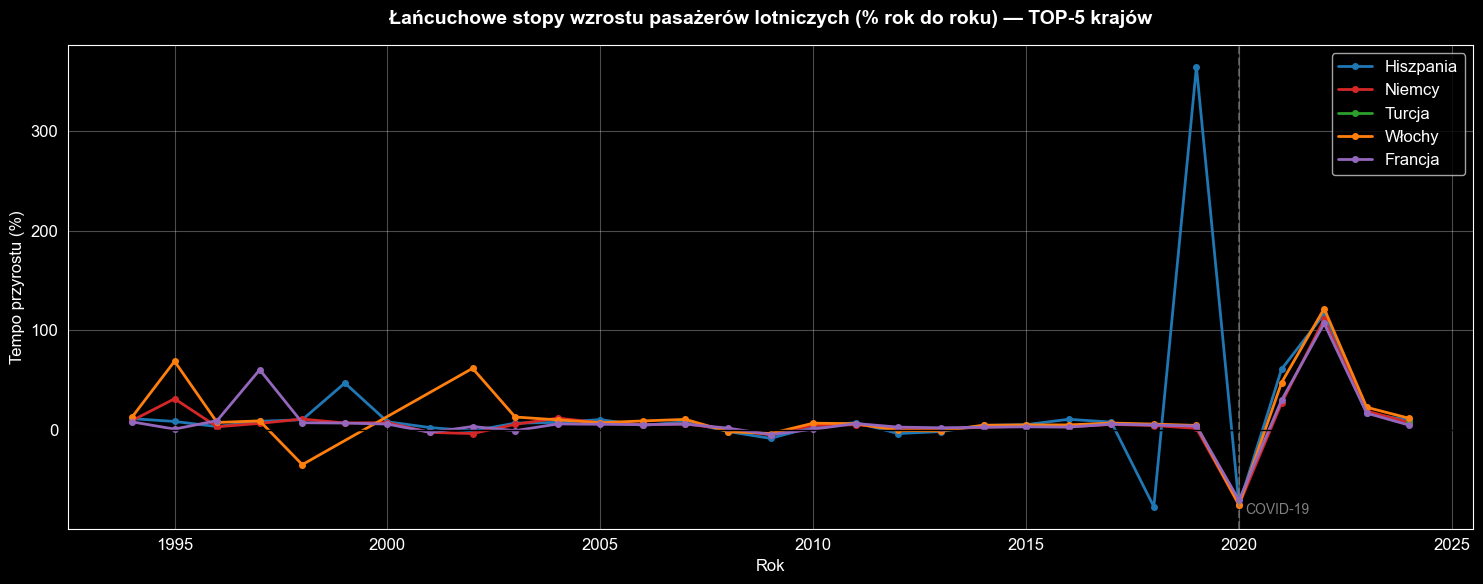

In [98]:
# Wykres 4: Łańcuchowe stopy wzrostu
fig, ax = plt.subplots(figsize=(15, 6))
for i, country in enumerate(TOP5):
    growth = df_growth.loc[country].dropna()
    ax.plot(growth.index, growth.values, marker='o', markersize=4,
            linewidth=2, label=country, color=colors[i])

ax.axhline(y=0, color='black', linewidth=1)
ax.set_title('Łańcuchowe stopy wzrostu pasażerów lotniczych (% rok do roku) — ТОP-5 krajów',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Rok', fontsize=12)
ax.set_ylabel('Tempo przyrostu (%)', fontsize=12)
ax.legend(fontsize=12)
if 2020 in df_pivot.columns:
    ax.axvline(x=2020, color='gray', linestyle='--', alpha=0.6)
    ax.text(2020.15, ax.get_ylim()[0]*0.85, 'COVID-19', color='gray', fontsize=10)
plt.tight_layout()
plt.show()

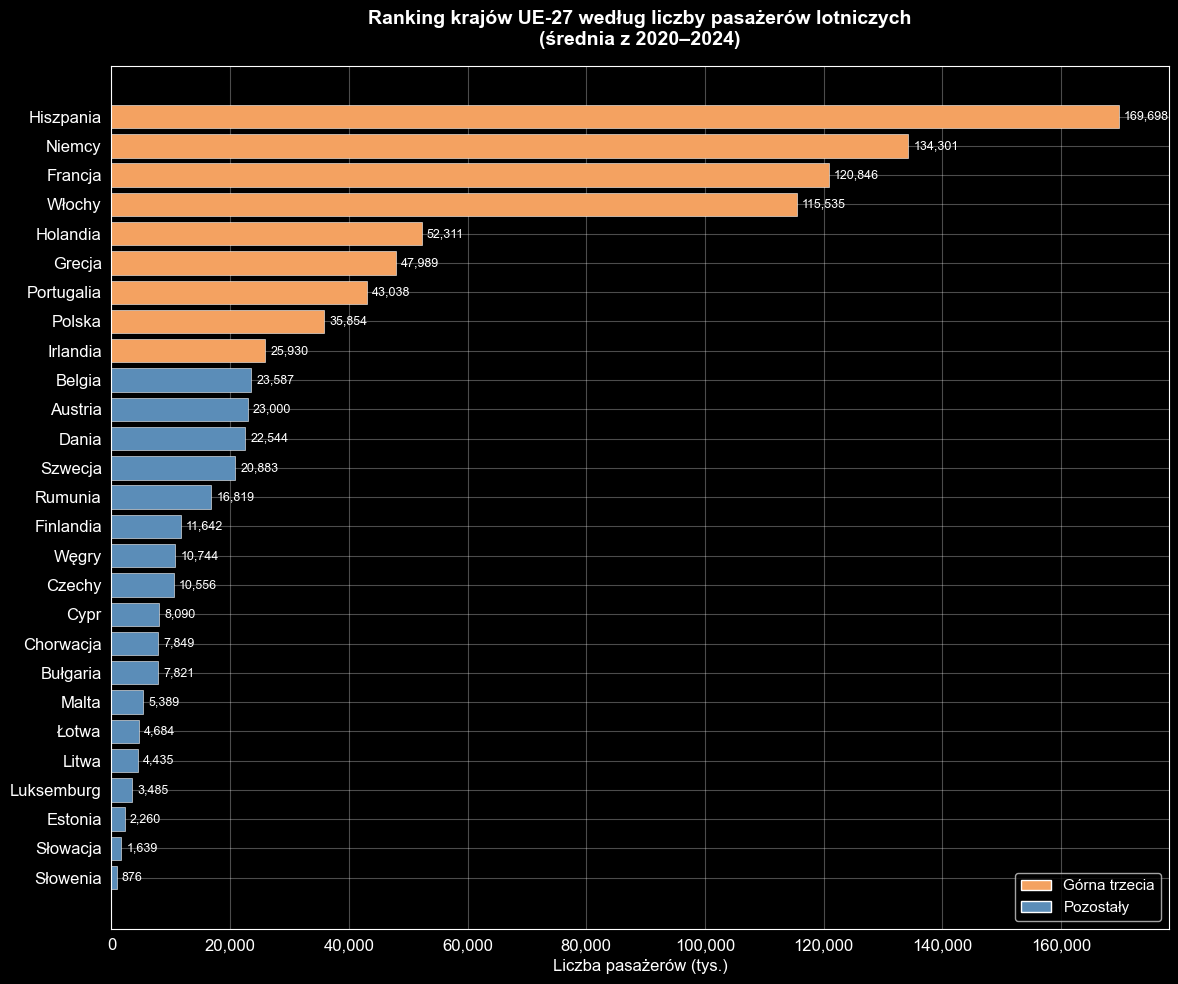

In [99]:
# Wykres 5: Ranking krajów UE-27
# Porównanie średniej z ostatnich 5 lat

recent_years = [y for y in df_pivot.columns if y >= LATEST_YEAR - 4]
df_eu27_recent = df_eu27[recent_years].mean(axis=1).dropna().sort_values()

fig, ax = plt.subplots(figsize=(12, 10))
bar_h = ax.barh(
    df_eu27_recent.index,
    df_eu27_recent.values,
    color=[
        '#f4a261' if df_eu27_recent[c] >= df_eu27_recent.quantile(0.66) else
        '#5B8DB8'
        for c in df_eu27_recent.index
    ],
    edgecolor='white', linewidth=0.4
)

for bar, val in zip(bar_h, df_eu27_recent.values):
    ax.text(val + df_eu27_recent.max()*0.005, bar.get_y() + bar.get_height()/2,
            f'{val/1000:.1f}M' if val >= 1e6 else f'{val:,.0f}',
            va='center', fontsize=9)

ax.set_title(f'Ranking krajów UE-27 według liczby pasażerów lotniczych\n(średnia z {recent_years[0]}–{recent_years[-1]})',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Liczba pasażerów (tys.)', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}M' if x >= 1e6 else f'{x:,.0f}'))

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#f4a261', label='Górna trzecia'),
    Patch(facecolor='#5B8DB8', label='Pozostały'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()


## Wyniki

**1. Struktura danych:**
Zbiór danych `tran_r_avpa_nm` zawiera dane o liczbie pasażerów lotniczych przewiezionych przez lotniska w krajach europejskich. Po przefiltrowaniu według poziomu kraju (2-znakowe kody) pozostaje kompaktowa tabela „kraj × rok”.

**2. Liderzy rynku:**
Bezsprzecznymi liderami pod względem liczby pasażerów lotniczych są Niemcy, Hiszpania, Wielka Brytania, Francja i Włochy. Odpowiada to wielkości ich gospodarek i natężeniu ruchu turystycznego.

**3. Wpływ COVID-19:**
Na wykresach dynamiki wyraźnie widać załamanie z 2020 roku (spadek o 70–80% we wszystkich krajach), spowodowane pandemią COVID-19, oraz następne odbudowanie w kształcie litery V w latach 2021–2023.

**4. Udziały w rynku:**
Wykres dynamiki liczby pasażerów pokazuje, że stosunek krajów liderów pozostaje stosunkowo stabilny przez cały okres, co świadczy o strukturalnej stabilności europejskiego rynku lotniczego.

**5. Nierównomierność:**
Ranking UE-27 wyraźnie pokazuje głęboką przepaść między dużymi a małymi krajami: ruch pasażerski w Niemczech lub Hiszpanii przekracza wskaźniki Luksemburga lub Malty setki razy.